Inspect schema — understand cast, directors, genres, reviews structure

## Imports

Standard data stack: `datasets` for Hugging Face loading, `pandas` for inspection, `matplotlib` + `seaborn` for distribution plots.

In [1]:
from pathlib import Path
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Configuration

Set up paths for raw data storage and define the Hugging Face dataset identifier.

In [2]:
DATA_DIR = Path("../../../data")
RAW_DIR = DATA_DIR / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME = "pkchwy/letterboxd-all-movie-data"

## Load Dataset

Fetch the dataset from Hugging Face. This downloads and caches ~847k film records. The `train` split contains all data — there is no test/validation split.

In [3]:
ds = load_dataset(DATASET_NAME)
df = ds["train"].to_pandas()
print(f"Loaded {len(df):,} films")

Loaded 847,209 films


## Inspect Schema: First Look
Let's start by using `df.head()` to see the first few rows. This gives us a raw look at the columns and the data format within them, such as how lists of dictionaries are stored for `cast`, `genres`, and `directors`.

In [4]:
df.head(3)

,url,title,year,directors,genres,cast,synopsis,rating,reviews,poster_url
0,https://letterboxd.com/film/come-and-see/,Come and See,1985,[Elem Klimov],"[War, Drama]","[Aleksei Kravchenko, Olga Mironova, Liubomiras...",The invasion of a village in Byelorussia by Ge...,4.62 out of 5,"[{'username': 'cameron fetter', 'review_text':...",https://a.ltrbxd.com/resized/film-poster/3/6/1...
1,https://letterboxd.com/film/seven-samurai/,Seven Samurai,1954,[Akira Kurosawa],"[Action, Drama]","[Toshirō Mifune, Takashi Shimura, Yoshio Inaba...",A samurai answers a village's request for prot...,4.61 out of 5,"[{'username': 'maria', 'review_text': 'too man...",https://a.ltrbxd.com/resized/film-poster/5/1/7...
2,https://letterboxd.com/film/high-and-low/,High and Low,1963,[Akira Kurosawa],"[Mystery, Thriller, Crime, Drama]","[Toshirō Mifune, Tatsuya Nakadai, Kyōko Kagawa...",In the midst of an attempt to take over his co...,4.60 out of 5,"[{'username': 'Karsten', 'review_text': 'every...",https://a.ltrbxd.com/resized/film-poster/4/4/5...


## Inspect Schema: Data Types and Nulls

Now, let's use `df.info()` to get a technical summary of the DataFrame. This is crucial for seeing the data type of each column (e.g., `object`, `int64`, `float64`) and, more importantly, the count of non-null values. A discrepancy between the total entry count and a column's non-null count immediately signals missing data that we'll need to handle later.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 847209 entries, 0 to 847208
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   url         847209 non-null  str   
 1   title       847209 non-null  str   
 2   year        770792 non-null  str   
 3   directors   732443 non-null  object
 4   genres      638857 non-null  object
 5   cast        595214 non-null  object
 6   synopsis    727899 non-null  str   
 7   rating      108834 non-null  str   
 8   reviews     366600 non-null  object
 9   poster_url  847209 non-null  str   
dtypes: object(4), str(6)
memory usage: 392.7+ MB


## Inspect Schema: Array Columns

The `cast`, `directors`, and `genres` columns are stored as lists of strings. Let's look at a sample row to see how this is formatted.

In [6]:
sample_row = df.iloc[0]

print("Directors:", sample_row['directors'])
print("Genres:", sample_row['genres'])
print("Cast (first 5):", sample_row['cast'][:5])

Directors: ['Elem Klimov']
Genres: ['War' 'Drama']
Cast (first 5): ['Aleksei Kravchenko' 'Olga Mironova' 'Liubomiras Laucevicius'
 'Vladas Bagdonas' 'Jüri Lumiste']


## Inspect Schema: Reviews

The `reviews` column is a list of dictionaries. Let's look at the structure of a single review to understand the fields available.

In [7]:
film_with_reviews = df.dropna(subset=['reviews'])
film_with_reviews = film_with_reviews[film_with_reviews['reviews'].apply(lambda x: len(x) > 0)].iloc[0]

sample_review = film_with_reviews['reviews'][0]

print(f"Film: {film_with_reviews['title']}")
print("Review keys:", sample_review.keys())
print("Sample Review Data:")
for k, v in sample_review.items():
    print(f"  {k}: {v}")

Film: Come and See
Review keys: dict_keys(['username', 'review_text', 'likes'])
Sample Review Data:
  username: cameron fetter
  review_text: as soon as this film ended i went online and enlisted in the US army. no child will ever suffer like this again on my watch
  likes: 11662


## Basic Distributions

Let's look at a few quick distributions to get a feel for the dataset's coverage, specifically looking at the release years.

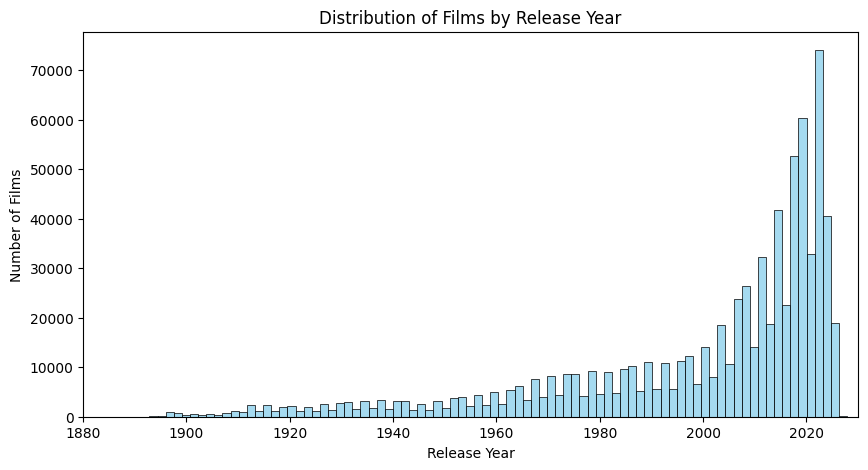

In [8]:
df['year_num'] = pd.to_numeric(df['year'], errors='coerce')

plt.figure(figsize=(10, 5))
sns.histplot(df['year_num'].dropna(), bins=100, color='skyblue')
plt.title('Distribution of Films by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Films')
plt.xlim(1880, 2030)
plt.show()